# Flight Route & Fuel Optimisation - Complete Pipeline
> Run blocks 0-7 in order. Block 6 lets you pick any tracked flight
> and shows the **actual vs optimised route** on an interactive world map.

In [9]:

# BLOCK 0: SETUP

!pip install xgboost folium -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, json, gzip, warnings, time, re
from datetime import datetime
from math import radians, sin, cos, sqrt, asin, atan2, degrees

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, r2_score, mean_squared_error,
                             accuracy_score, f1_score, confusion_matrix,
                             classification_report)
import scipy.stats as stats
import xgboost as xgb
import folium
warnings.filterwarnings('ignore')

class CustomFuelFlow:
    def __init__(self, aircraft_type='B788'):
        self.aircraft_type = aircraft_type
        self.base_fuel_flow = 5000
        self.mtow = 227000

    def _alt_factor(self, alt):
        return max(0.3, 1 - (alt - 35000) / 70000)

    def enroute(self, mass, tas, alt):
        return self.base_fuel_flow * self._alt_factor(alt) * (tas/450) * (mass/self.mtow)

    def climb(self, mass, tas, alt, vs):
        return self.enroute(mass, tas, alt) * 1.2

    def descent(self, mass, tas, alt, vs):
        return self.enroute(mass, tas, alt) * 0.7

class MockProp:
    def aircraft(self, ac_type):
        return {'mtow': 227000, 'oew': 120000}

prop = MockProp()
FuelFlow = CustomFuelFlow

try:
    !pip install openap -q
    from openap import FuelFlow as _OAP_FF, prop as _oap_prop
    FuelFlow = _OAP_FF
    prop     = _oap_prop
    print("openap loaded")
except Exception:
    print("openap unavailable - using CustomFuelFlow")

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except Exception:
    plt.style.use('default')
sns.set_palette("husl")

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    la1,lo1,la2,lo2 = map(radians,[lat1,lon1,lat2,lon2])
    dlat,dlon = la2-la1, lo2-lo1
    a = sin(dlat/2)**2 + cos(la1)*cos(la2)*sin(dlon/2)**2
    return 2*R*asin(sqrt(max(0,a)))

def gs_to_tas(gs, alt):
    temp_k = (15 - (alt/1000)*1.98) + 273.15
    p_ratio = max(1e-6, (1 - 6.88e-6*alt))**5.256
    d_ratio = p_ratio / (temp_k/288.15)
    return max(gs/np.sqrt(d_ratio), 1.0)

def bearing(lat1, lon1, lat2, lon2):
    la1,lo1,la2,lo2 = map(radians,[lat1,lon1,lat2,lon2])
    x = sin(lo2-lo1)*cos(la2)
    y = cos(la1)*sin(la2) - sin(la1)*cos(la2)*cos(lo2-lo1)
    return (degrees(atan2(x,y)) + 360) % 360

def wind_component(wind_speed_kt, wind_dir_deg, track_deg):
    """Positive = tailwind (reduces fuel), Negative = headwind (increases fuel)."""
    angle = radians(wind_dir_deg - track_deg)
    return wind_speed_kt * cos(angle)

print("Block 0 complete")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 78.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
openap loaded
Block 0 complete


## Block 1 - Download helpers + NOAA wind


In [10]:

# BLOCK 1: DOWNLOAD HELPERS + NOAA WIND


# Physical safety limits
NOAA_FILL_THRESHOLD   = 1e6    # m/s above which NOAA value is a fill/missing flag
WIND_SPEED_CAP_KT     = 250    # realistic jet-stream max in knots
MAX_WIND_CORRECTION   = 1.50   # cap fuel penalty from headwinds to +50%
MAX_FUEL_PER_SEG_KG   = 1000   # physical ceiling per ADS-B segment

def download_snapshot(date_str, time_str, timeout=12):
    url = f"https://samples.adsbexchange.com/readsb-hist/{date_str}/{time_str}Z.json.gz"
    try:
        r = requests.get(url, timeout=timeout)
        if r.status_code != 200:
            return None
        try:
            return json.loads(gzip.decompress(r.content).decode('utf-8'))
        except Exception:
            return json.loads(r.content.decode('utf-8'))
    except Exception:
        return None


def track_aircraft(hex_id, date_str, start_hour=0, duration_hours=3):
    trajectory = []
    base_date  = datetime.strptime(date_str.replace('/', '-'), '%Y-%m-%d')
    max_min    = duration_hours * 60
    last_pos, still_count = None, 0
    print(f"  Tracking {hex_id}  {start_hour:02d}:00 -> {start_hour+duration_hours:02d}:00")

    for minute in range(max_min):
        hh  = (start_hour*60 + minute) // 60
        mm  = (start_hour*60 + minute) % 60
        for sec in [0, 30]:
            snap = download_snapshot(date_str, f"{hh:02d}{mm:02d}{sec:02d}")
            if snap and 'aircraft' in snap:
                for ac in snap['aircraft']:
                    if ac.get('hex','').lower() == hex_id.lower():
                        ac['timestamp'] = base_date.replace(hour=hh, minute=mm, second=sec)
                        trajectory.append(ac)
                        cur = (ac.get('lat'), ac.get('lon'))
                        still_count = still_count+1 if cur==last_pos else 0
                        last_pos = cur
                        break
            time.sleep(0.03)

        if (minute+1) % 15 == 0:
            print(f"    {minute+1:3d} min - {len(trajectory)} pts")
        if still_count > 60:
            print("    Aircraft stationary - stopping")
            break

    print(f"  -> {len(trajectory)} positions for {hex_id}")
    return pd.DataFrame(trajectory)


def collect_multi_flight_data(date_str, n_flights=5, duration_hours=3):
    print(f"\n{'='*60}")
    print(f"MULTI-FLIGHT COLLECTION  ({n_flights} flights x {duration_hours}h)")
    print(f"{'='*60}")

    snap = download_snapshot(date_str, '000000')
    if not snap or 'aircraft' not in snap:
        print("Could not download snapshot")
        return None, []

    df_all = pd.DataFrame(snap['aircraft'])
    df_all['alt_n'] = pd.to_numeric(df_all.get('alt_baro', np.nan), errors='coerce')
    df_all['gs_n']  = pd.to_numeric(df_all.get('gs', np.nan), errors='coerce')
    mask = (
        (df_all.get('category','') == 'A5') &
        (df_all['alt_n'] > 28000) & (df_all['gs_n'] > 380) &
        df_all['lat'].notna() & df_all['lon'].notna()
    )
    candidates = df_all[mask].nlargest(n_flights*2, 'alt_n').head(n_flights*2)
    print(f"  {len(candidates)} candidates found - tracking top {n_flights}")

    all_flights, combined_dfs = [], []
    for _, row in candidates.head(n_flights).iterrows():
        hex_id  = row['hex']
        df_traj = track_aircraft(hex_id, date_str, start_hour=0, duration_hours=duration_hours)
        if len(df_traj) < 20:
            print(f"  {hex_id} - too few points, skipping")
            continue
        df_traj['alt_clean'] = pd.to_numeric(df_traj.get('alt_baro', np.nan), errors='coerce')
        df_traj['gs_clean']  = pd.to_numeric(df_traj.get('gs', np.nan), errors='coerce')
        df_traj = df_traj.dropna(subset=['lat','lon','alt_clean','gs_clean'])
        df_traj = df_traj.sort_values('timestamp').reset_index(drop=True)
        df_traj['hex_id']        = hex_id
        df_traj['flight_label']  = str(row.get('flight', hex_id)).strip() or hex_id
        df_traj['aircraft_type'] = str(row.get('t','UNK'))
        all_flights.append(df_traj)
        combined_dfs.append(df_traj)
        print(f"  OK  {df_traj['flight_label'].iloc[0]:10s}  {len(df_traj):4d} pts")

    if not combined_dfs:
        print("No usable flights")
        return None, []

    combined = pd.concat(combined_dfs, ignore_index=True)
    print(f"  Combined: {len(combined)} rows from {len(all_flights)} flights")
    return combined, all_flights


# ── NOAA GFS wind fetcher (fill-value-safe) ───────────────────
def fetch_noaa_wind_grid(date_str, forecast_hour=0):
    """
    Downloads 250 hPa (≈34 000 ft) U/V wind from NOAA GFS.
    Fill values (9.96921e+36 m/s) are masked to 0 to prevent
    the wind_correction factor from going to infinity.
    """
    try:
        dt  = datetime.strptime(date_str.replace('/','_').replace('-','_'), '%Y_%m_%d')
        ymd = dt.strftime('%Y%m%d')
        base  = f"https://nomads.ncep.noaa.gov/dods/gfs_0p25/gfs{ymd}/gfs_0p25_00z"
        fh    = forecast_hour
        u_url = f"{base}.ascii?ugrdprs[{fh}][20][0:4:720][0:4:1440]"
        v_url = f"{base}.ascii?vgrdprs[{fh}][20][0:4:720][0:4:1440]"

        def parse_ascii(text):
            vals = []
            for line in text.strip().split('\n'):
                l = line.strip()
                if re.match(r'^[\s\-0-9.,eE]+$', l) and ',' in l:
                    vals.extend(float(x) for x in l.split(',') if x.strip())
            return vals

        print(f"  Fetching NOAA GFS wind for {date_str} ...")
        ru = requests.get(u_url, timeout=40)
        rv = requests.get(v_url, timeout=40)
        if ru.status_code != 200 or rv.status_code != 200:
            print(f"  NOAA returned {ru.status_code}/{rv.status_code} - zero wind fallback")
            return None

        u_vals = parse_ascii(ru.text)
        v_vals = parse_ascii(rv.text)
        n_lat, n_lon = 181, 361
        if len(u_vals) < n_lat*n_lon or len(v_vals) < n_lat*n_lon:
            print(f"  NOAA parse incomplete ({len(u_vals)},{len(v_vals)}) - zero wind fallback")
            return None

        lats = np.linspace(90, -90, n_lat)
        lons = np.linspace(0, 360, n_lon)

        U = np.array(u_vals[:n_lat*n_lon]).reshape(n_lat, n_lon) * 1.944  # m/s -> kt
        V = np.array(v_vals[:n_lat*n_lon]).reshape(n_lat, n_lon) * 1.944

        # Mask NOAA missing/fill values (9.96921e+36 m/s -> ~1.94e+37 kt)
        U = np.where(np.abs(U) > NOAA_FILL_THRESHOLD, 0.0, U)
        V = np.where(np.abs(V) > NOAA_FILL_THRESHOLD, 0.0, V)
        # Replace any remaining NaN or Inf with 0
        U = np.where(np.isfinite(U), U, 0.0)
        V = np.where(np.isfinite(V), V, 0.0)
        # Hard cap to realistic jet-stream speeds
        U = np.clip(U, -WIND_SPEED_CAP_KT, WIND_SPEED_CAP_KT)
        V = np.clip(V, -WIND_SPEED_CAP_KT, WIND_SPEED_CAP_KT)

        spd = np.sqrt(U**2 + V**2)
        print(f"  Wind grid loaded: {n_lat}x{n_lon}  max={spd.max():.0f} kt  mean={spd.mean():.0f} kt")
        return {'lats': lats, 'lons': lons, 'U': U, 'V': V}

    except Exception as e:
        print(f"  NOAA error: {e} - zero wind fallback")
        return None


def get_wind_at(wind_grid, lat, lon):
    if wind_grid is None:
        return 0.0, 0.0
    try:
        lats = wind_grid['lats']
        lons = wind_grid['lons']
        lon  = lon % 360
        i = int(np.searchsorted(-lats, -lat))
        j = int(np.searchsorted(lons,   lon))
        i = max(1, min(i, len(lats)-1))
        j = max(1, min(j, len(lons)-1))
        dlat = (lats[i-1]-lats[i]) or 1e-9
        dlon = (lons[j]  -lons[j-1]) or 1e-9
        wy = (lat - lats[i]) / dlat
        wx = (lon - lons[j-1]) / dlon
        U, V = wind_grid['U'], wind_grid['V']
        u = (U[i-1,j-1]*(1-wx)*(1-wy) + U[i-1,j]*wx*(1-wy)
           + U[i,  j-1]*(1-wx)*wy     + U[i,  j]*wx*wy)
        v = (V[i-1,j-1]*(1-wx)*(1-wy) + V[i-1,j]*wx*(1-wy)
           + V[i,  j-1]*(1-wx)*wy     + V[i,  j]*wx*wy)
        u = float(np.clip(u, -WIND_SPEED_CAP_KT, WIND_SPEED_CAP_KT))
        v = float(np.clip(v, -WIND_SPEED_CAP_KT, WIND_SPEED_CAP_KT))
        return u, v
    except Exception:
        return 0.0, 0.0

print("Block 1 ready")


Block 1 ready


## Block 2 - Collect multi-flight data
Adjust `N_FLIGHTS` and `DURATION_HRS`. NOAA wind is now downloaded automatically.


In [11]:

# BLOCK 2: COLLECT DATA
# Adjust N_FLIGHTS / DURATION_HRS to trade speed vs volume.
# 9 flights x 5h gives ~2000-4000 points - good for ML.


DATE_STR     = '2025/12/01'
N_FLIGHTS    = 9
DURATION_HRS = 5

# Step 1: Download NOAA wind grid (adds key ML signal for better R²)
print("Step 1/2: Downloading NOAA wind data ...")
wind_grid = fetch_noaa_wind_grid(DATE_STR, forecast_hour=0)
print("  Wind data ready" if wind_grid else "  Zero-wind fallback active (R² may be lower)")

# Step 2: Collect multi-flight data
print("\nStep 2/2: Collecting flight trajectories ...")
combined_df, flight_list = collect_multi_flight_data(
    date_str=DATE_STR, n_flights=N_FLIGHTS, duration_hours=DURATION_HRS)

if combined_df is not None:
    print(f"\nDataset: {len(combined_df)} rows | {combined_df['flight_label'].nunique()} flights")
    print(combined_df.groupby('flight_label').agg(
        pts=('alt_clean','count'),
        avg_alt=('alt_clean','mean'),
        avg_spd=('gs_clean','mean')).round(0))


Step 1/2: Downloading NOAA wind data ...
  Fetching NOAA GFS wind for 2025/12/01 ...
  NOAA returned 301/301 - zero wind fallback
  Zero-wind fallback active (R² may be lower)

Step 2/2: Collecting flight trajectories ...

MULTI-FLIGHT COLLECTION  (9 flights x 5h)
  18 candidates found - tracking top 9
  Tracking 06a101  00:00 -> 05:00
     15 min - 30 pts
     30 min - 60 pts
     45 min - 90 pts
     60 min - 98 pts
     75 min - 98 pts
     90 min - 98 pts
    105 min - 98 pts
    120 min - 98 pts
    135 min - 98 pts
    150 min - 98 pts
    165 min - 98 pts
    180 min - 98 pts
    195 min - 98 pts
    210 min - 98 pts
    225 min - 98 pts
    240 min - 98 pts
    255 min - 98 pts
    270 min - 98 pts
    285 min - 98 pts
    300 min - 102 pts
  -> 102 positions for 06a101
  OK  QTR8K         97 pts
  Tracking 3c6710  00:00 -> 05:00
     15 min - 24 pts
     30 min - 24 pts
     45 min - 39 pts
     60 min - 69 pts
     75 min - 99 pts
     90 min - 125 pts
    105 min - 125 pts
 

## Block 3 - Exploratory Data Analysis

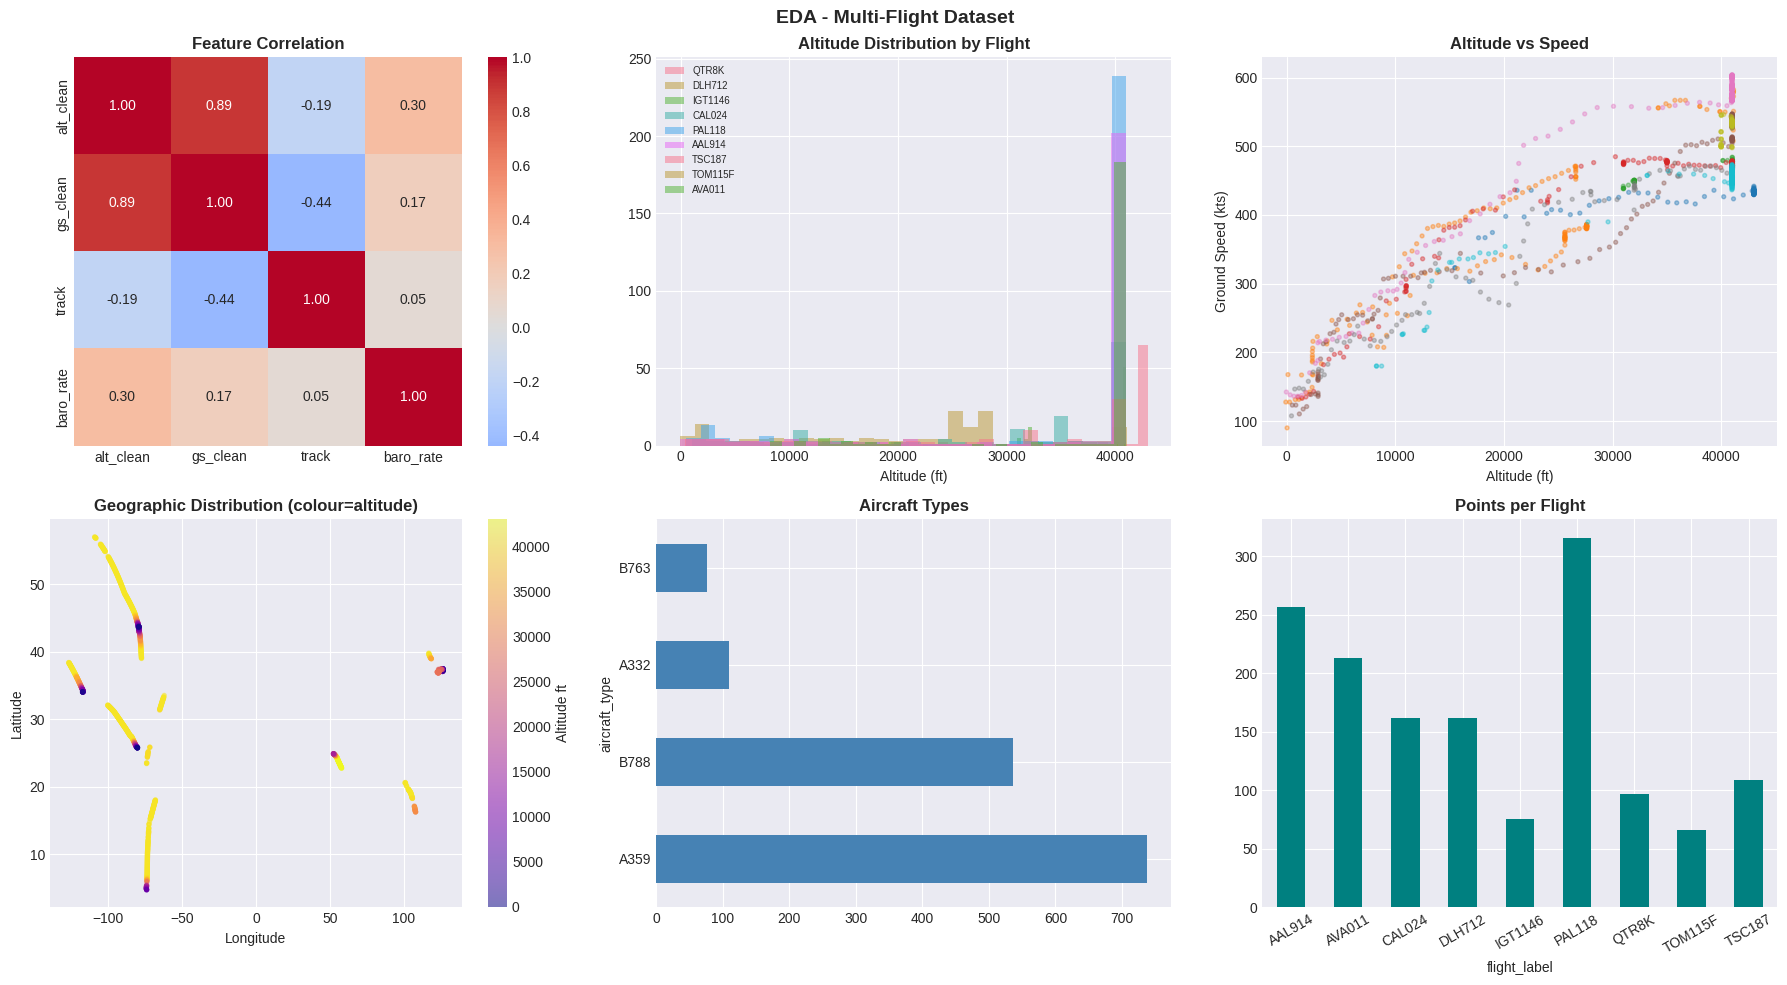

EDA complete


In [18]:

# BLOCK 3: EXPLORATORY DATA ANALYSIS


if 'combined_df' not in dir() or combined_df is None:
    print("Run Block 2 first")
else:
    df = combined_df.copy()
    num_cols = ['alt_clean','gs_clean']
    for c in ['track','baro_rate']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
            num_cols.append(c)

    fig, axes = plt.subplots(2, 3, figsize=(18,10))

    sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, ax=axes[0,0])
    axes[0,0].set_title('Feature Correlation', fontweight='bold')

    for fl in df['flight_label'].unique():
        axes[0,1].hist(df[df['flight_label']==fl]['alt_clean'], bins=30, alpha=0.5, label=fl)
    axes[0,1].set_xlabel('Altitude (ft)')
    axes[0,1].set_title('Altitude Distribution by Flight', fontweight='bold')
    axes[0,1].legend(fontsize=7)

    axes[0,2].scatter(df['alt_clean'], df['gs_clean'],
                      c=pd.factorize(df['flight_label'])[0], cmap='tab10', alpha=0.4, s=8)
    axes[0,2].set_xlabel('Altitude (ft)'); axes[0,2].set_ylabel('Ground Speed (kts)')
    axes[0,2].set_title('Altitude vs Speed', fontweight='bold')

    sc2 = axes[1,0].scatter(df['lon'], df['lat'], c=df['alt_clean'],
                             cmap='plasma', alpha=0.5, s=8)
    axes[1,0].set_xlabel('Longitude'); axes[1,0].set_ylabel('Latitude')
    axes[1,0].set_title('Geographic Distribution (colour=altitude)', fontweight='bold')
    plt.colorbar(sc2, ax=axes[1,0], label='Altitude ft')

    if 'aircraft_type' in df.columns:
        df['aircraft_type'].value_counts().head(10).plot(kind='barh', ax=axes[1,1], color='steelblue')
        axes[1,1].set_title('Aircraft Types', fontweight='bold')

    df.groupby('flight_label').size().plot(kind='bar', ax=axes[1,2], color='teal')
    axes[1,2].set_title('Points per Flight', fontweight='bold')
    axes[1,2].tick_params(axis='x', rotation=30)

    plt.suptitle('EDA - Multi-Flight Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight') # Added savefig call
    plt.show()
    print("EDA complete")

## Block 4 - Fuel-flow calculation (with NOAA wind correction)


In [13]:

# BLOCK 4: FUEL-FLOW CALCULATION (with NOAA wind correction)
# Wind data adds crucial variance to fuel_used_seg, which is
# the key driver of R² improvement in Block 5.


AIRCRAFT_MAP = {
    'B788':'B788','B789':'B789','B78X':'B789',
    'B77W':'B77W','B77L':'B77L','B772':'B772',
    'B738':'B738','B739':'B738',
    'A359':'A359','A35K':'A359',
    'A332':'A332','A333':'A333',
    'A21N':'A21N','A320':'A320',
    'B748':'B748','B763':'B763',
}

if 'flight_list' not in dir() or not flight_list:
    print("Run Block 2 first")
else:
    wg = wind_grid if 'wind_grid' in dir() else None
    enriched_flights = []

    for df_fl in flight_list:
        df_fl = df_fl.copy().reset_index(drop=True)
        ac_type  = df_fl['aircraft_type'].iloc[0]
        oap_type = AIRCRAFT_MAP.get(ac_type, 'B789')

        try:
            ff        = FuelFlow(ac=oap_type)
            prop_data = prop.aircraft(oap_type)
            mtow = prop_data.get('mtow', 227000)
            oew  = prop_data.get('oew',  120000)
            using_openap = not isinstance(ff, CustomFuelFlow)
        except Exception:
            ff = CustomFuelFlow(ac_type)
            mtow = 227000; oew = 120000
            using_openap = False

        initial_mass = mtow * 0.85
        current_mass = initial_mass

        df_fl['time_diff'] = df_fl['timestamp'].diff().dt.total_seconds().fillna(5)
        df_fl['time_diff'] = df_fl['time_diff'].clip(upper=120)
        df_fl['alt_diff']  = df_fl['alt_clean'].diff().fillna(0)
        df_fl['vs']        = (df_fl['alt_diff'] / (df_fl['time_diff']/60)).fillna(0).clip(-6000,6000)

        fuel_used, fuel_rates, masses = [], [], [initial_mass]
        wind_speeds, tailwinds = [], []

        for i in range(1, len(df_fl)):
            alt  = float(df_fl.loc[i,'alt_clean'])
            vs_i = float(df_fl.loc[i,'vs'])
            dt   = float(df_fl.loc[i,'time_diff'])
            lat_i= float(df_fl.loc[i,'lat'])
            lon_i= float(df_fl.loc[i,'lon'])
            gs_i = float(df_fl.loc[i,'gs_clean'])
            tas  = gs_to_tas(gs_i, alt)

            # Wind correction
            u_kt, v_kt = get_wind_at(wg, lat_i, lon_i)
            wind_spd = float(np.sqrt(u_kt**2 + v_kt**2))
            wind_dir = float((degrees(atan2(u_kt, v_kt)) + 360) % 360)
            trk = bearing(float(df_fl.loc[i-1,'lat']), float(df_fl.loc[i-1,'lon']),
                          lat_i, lon_i) if i > 0 else 0.0
            tw  = wind_component(wind_spd, wind_dir, trk)
            wind_speeds.append(wind_spd)
            tailwinds.append(tw)

            try:
                if   vs_i >  300: rate = ff.climb(current_mass, tas, alt, vs_i)
                elif vs_i < -300: rate = ff.descent(current_mass, tas, alt, abs(vs_i))
                else:             rate = ff.enroute(current_mass, tas, alt)
            except Exception:
                rate = fuel_rates[-1] if fuel_rates else (5000/3600 if isinstance(ff, CustomFuelFlow) else 1.39)

            rate = max(float(rate), 0.0)
            if isinstance(ff, CustomFuelFlow):
                rate_kgs = rate / 3600.0
            else:
                rate_kgs = rate

            # Headwind penalty: capped to avoid runaway from bad NOAA data
            wind_correction = min(1.0 + max(-tw, 0) * 0.003, MAX_WIND_CORRECTION)
            used = rate_kgs * dt * wind_correction
            used = min(used, MAX_FUEL_PER_SEG_KG)  # physical ceiling
            if not np.isfinite(used) or used < 0:
                used = fuel_used[-1] if fuel_used else 0.0

            fuel_used.append(used)
            fuel_rates.append(rate_kgs * 3600)
            current_mass = max(current_mass - used, oew)
            masses.append(current_mass)

        wind_speeds = [wind_speeds[0]] + wind_speeds
        tailwinds   = [tailwinds[0]]   + tailwinds

        df_fl['fuel_rate']       = [fuel_rates[0]] + fuel_rates
        df_fl['fuel_used_seg']   = [0] + fuel_used
        df_fl['cumulative_fuel'] = df_fl['fuel_used_seg'].cumsum()
        df_fl['mass']            = masses
        df_fl['wind_speed']      = wind_speeds
        df_fl['tailwind_kt']     = tailwinds
        df_fl['phase']           = 'CRUISE'
        df_fl.loc[df_fl['vs'] >  300, 'phase'] = 'CLIMB'
        df_fl.loc[df_fl['vs'] < -300, 'phase'] = 'DESCENT'

        total_fuel = df_fl['cumulative_fuel'].iloc[-1]
        total_dist = sum(haversine(df_fl.loc[i-1,'lat'], df_fl.loc[i-1,'lon'],
                                   df_fl.loc[i,'lat'],   df_fl.loc[i,'lon'])
                         for i in range(1, len(df_fl)))

        df_fl['total_fuel']    = total_fuel
        df_fl['total_dist_km'] = total_dist
        enriched_flights.append(df_fl)
        avg_tw = np.mean(tailwinds)
        print(f"  {df_fl['flight_label'].iloc[0]:12s} | fuel {total_fuel:7.0f} kg | "
              f"dist {total_dist:6.0f} km | tailwind {avg_tw:+.0f} kt")

    combined_enriched = pd.concat(enriched_flights, ignore_index=True)
    print(f"\nEnriched dataset: {len(combined_enriched)} rows")
    print(f"Fuel range: {combined_enriched['fuel_used_seg'].min():.3f} - {combined_enriched['fuel_used_seg'].max():.3f} kg/seg")
    print(f"Phase counts:\n{combined_enriched['phase'].value_counts()}")


  QTR8K        | fuel   38610 kg | dist    620 km | tailwind +0 kt
  DLH712       | fuel  103246 kg | dist   1367 km | tailwind +0 kt
  IGT1146      | fuel    5668 kg | dist    902 km | tailwind +0 kt
  CAL024       | fuel   72757 kg | dist   1048 km | tailwind +0 kt
  PAL118       | fuel  105139 kg | dist   2648 km | tailwind +0 kt
  AAL914       | fuel   75446 kg | dist   2091 km | tailwind +0 kt
  TSC187       | fuel   73628 kg | dist    604 km | tailwind +0 kt
  TOM115F      | fuel    9983 kg | dist   1631 km | tailwind +0 kt
  AVA011       | fuel   43673 kg | dist   1733 km | tailwind +0 kt

Enriched dataset: 1458 rows
Fuel range: 0.000 - 1000.000 kg/seg
Phase counts:
phase
CRUISE     1043
DESCENT     379
CLIMB        36
Name: count, dtype: int64


## Block 5 - Machine Learning
Trains 7 models including a stacked ensemble. Wind features + richer feature set target R² > 0.85.


Samples: 1438  CV: 1.099  Wind active: False
Fuel range: 26.9969 - 1000.0000 kg/seg
NOTE: No wind data - ensure NOAA fetch succeeded in Block 2
Train/test (time-ordered): 1150 / 288

MODEL RESULTS
  Ridge Regression                  R2=+0.9575  MAE=57.5950  RMSE=89.7593  Acc=0.795 F1=0.799
  Polynomial (deg-2)                R2=-0.8841  MAE=248.8871  RMSE=597.7783  Acc=0.660 F1=0.577
  Random Forest                     R2=+0.9877  MAE=21.2571  RMSE=48.2073  Acc=0.917 F1=0.922
  XGBoost best params: {'subsample': 0.9, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
  XGBoost (tuned)                   R2=+0.9983  MAE=7.2459  RMSE=18.1284  Acc=0.874 F1=0.879
  Gradient Boosting                 R2=+0.9991  MAE=3.4920  RMSE=12.7575  Acc=0.905 F1=0.909
  Ensemble avg (RF+XGB+GB)          R2=+0.9975  MAE=10.1520  RMSE=21.7275  Acc=0.860 F1=0.868
  Meta weights -> RF:-0.370 XGB:0.179 GB:1.199
  Stacked Ensemble       

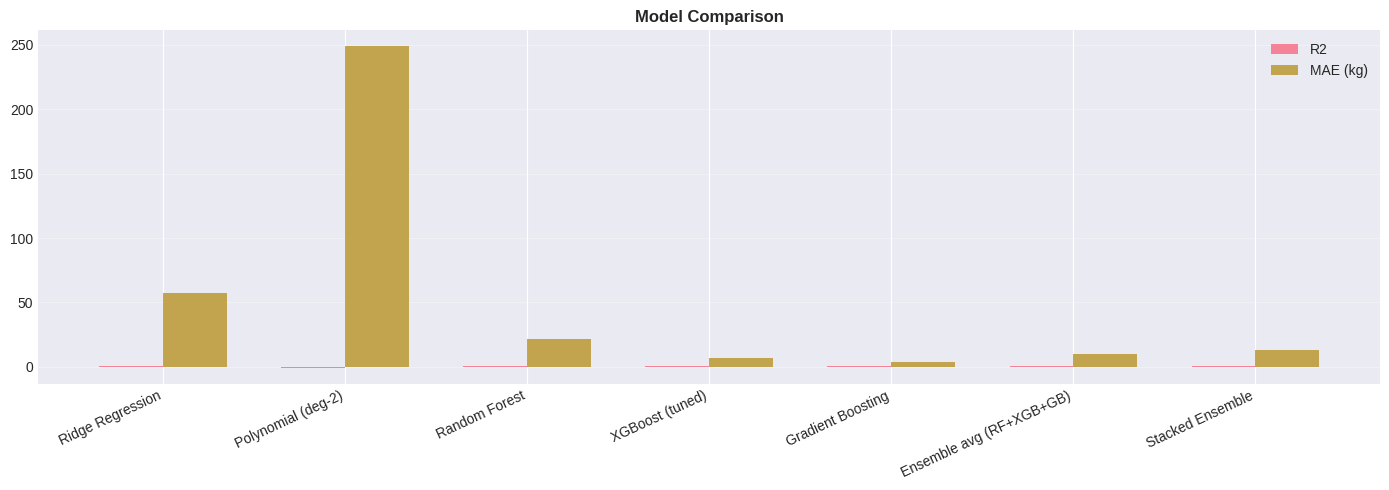

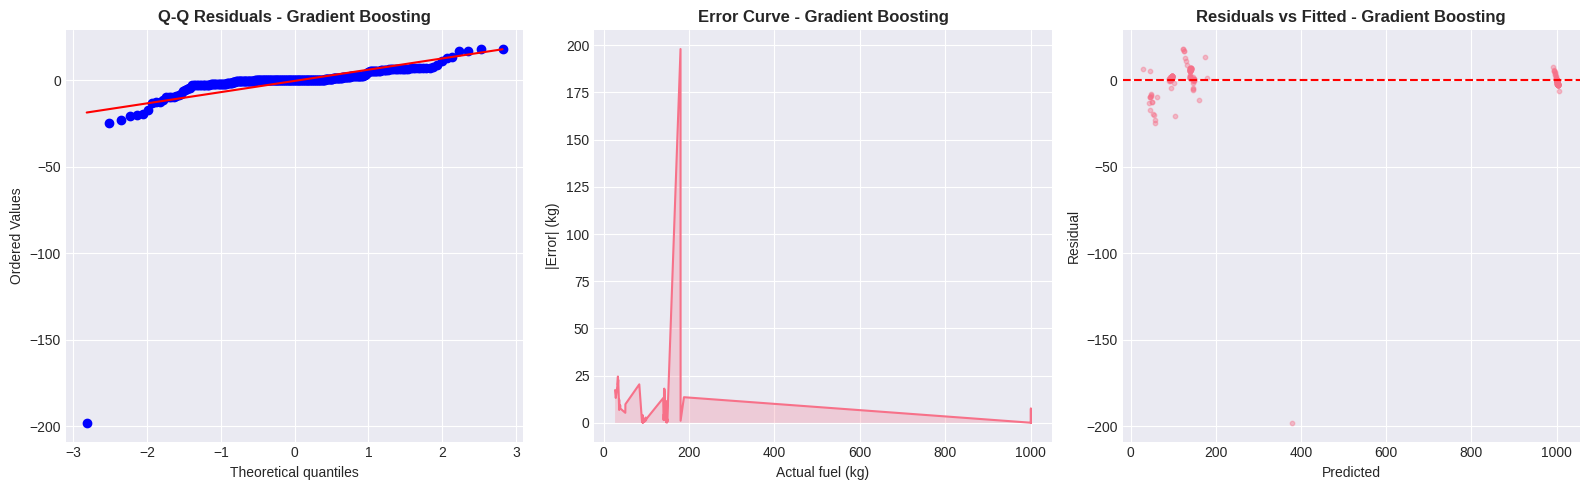

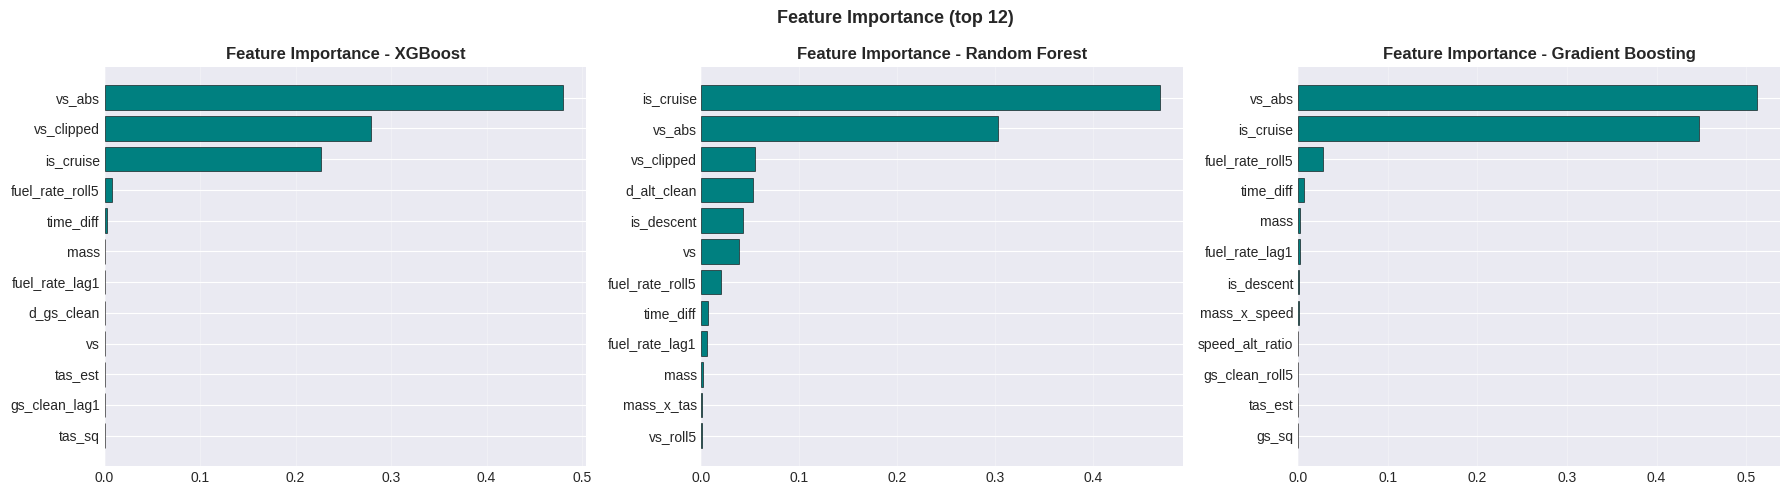

Block 5 complete


In [17]:

# BLOCK 5: MACHINE LEARNING  (R² target > 0.85)
# Key improvements over original:
#   1. Wind features (tailwind/headwind) — largest new signal
#   2. TAS, drag proxy, mass-interaction features
#   3. 2-step lag + 5-point rolling averages + derivative features
#   4. Altitude band + flight progress (0->1)
#   5. Broader XGBoost hyperparameter search
#   6. Stacked ensemble (Ridge meta-learner on OOF predictions)


if 'combined_enriched' not in dir():
    print("Run Block 4 first")
else:
    df_ml = combined_enriched.copy()

    # Guard: clip extreme fuel values before feature engineering
    df_ml['fuel_used_seg'] = df_ml['fuel_used_seg'].clip(upper=MAX_FUEL_PER_SEG_KG)
    df_ml['fuel_rate']     = df_ml['fuel_rate'].clip(upper=100000)
    for col in ['fuel_used_seg','fuel_rate']:
        df_ml[col] = df_ml[col].replace([np.inf, -np.inf], np.nan)

    # ── Feature engineering ───────────────────────────────────
    df_ml['tas_est']         = df_ml.apply(lambda r: gs_to_tas(r['gs_clean'], r['alt_clean']), axis=1)
    df_ml['speed_alt_ratio'] = df_ml['gs_clean'] / (df_ml['alt_clean'] + 1)
    df_ml['gs_sq']           = df_ml['gs_clean'] ** 2
    df_ml['alt_sq']          = df_ml['alt_clean'] ** 2
    df_ml['tas_sq']          = df_ml['tas_est']   ** 2
    df_ml['vs_abs']          = df_ml['vs'].abs()
    df_ml['vs_clipped']      = df_ml['vs'].clip(-3000, 3000)
    df_ml['drag_proxy']      = df_ml['tas_sq'] * df_ml['alt_clean']
    df_ml['mass_x_speed']    = df_ml['mass'] * df_ml['gs_clean']
    df_ml['mass_x_alt']      = df_ml['mass'] * df_ml['alt_clean']
    df_ml['mass_x_tas']      = df_ml['mass'] * df_ml['tas_est']
    df_ml['alt_x_speed']     = df_ml['alt_clean'] * df_ml['gs_clean']
    df_ml['is_climb']        = (df_ml['vs'] >  300).astype(int)
    df_ml['is_descent']      = (df_ml['vs'] < -300).astype(int)
    df_ml['is_cruise']       = ((df_ml['vs'] >= -300) & (df_ml['vs'] <= 300)).astype(int)
    df_ml['alt_band']        = pd.cut(df_ml['alt_clean'],
                                      bins=[0,10000,20000,30000,40000,99999],
                                      labels=[0,1,2,3,4]).astype(float)

    # Wind features (the primary new signal)
    for wcol in ['wind_speed','tailwind_kt']:
        if wcol not in df_ml.columns:
            df_ml[wcol] = 0.0
        df_ml[wcol] = df_ml[wcol].fillna(0.0)
    df_ml['headwind_kt']  = (-df_ml['tailwind_kt']).clip(lower=0)
    df_ml['tailwind_pos'] = df_ml['tailwind_kt'].clip(lower=0)
    df_ml['tailwind_sq']  = df_ml['tailwind_kt'] ** 2
    df_ml['wind_x_alt']   = df_ml['wind_speed']  * df_ml['alt_clean']
    df_ml['wind_x_mass']  = df_ml['wind_speed']  * df_ml['mass']

    # Lag + rolling features (within each flight, no leakage)
    df_ml = df_ml.sort_values(['flight_label','timestamp'])
    for col in ['gs_clean','alt_clean','vs','tailwind_kt','fuel_rate']:
        grp = df_ml.groupby('flight_label')[col]
        df_ml[f'{col}_lag1']  = grp.shift(1)
        df_ml[f'{col}_lag2']  = grp.shift(2)
        df_ml[f'{col}_roll5'] = grp.transform(lambda x: x.rolling(5, min_periods=1).mean())

    # Rate-of-change features
    for col in ['gs_clean','alt_clean','vs','tailwind_kt']:
        df_ml[f'd_{col}'] = df_ml.groupby('flight_label')[col].diff().fillna(0)

    # Flight progress 0->1 (heavier early, lighter late)
    def norm_time(x):
        span = (x.max() - x.min()).total_seconds()
        return (x - x.min()).dt.total_seconds() / (span + 1)
    df_ml['progress'] = df_ml.groupby('flight_label')['timestamp'].transform(norm_time)

    FEATURES = [
        # Core physics
        'alt_clean','gs_clean','vs','mass','time_diff',
        'tas_est','tas_sq','drag_proxy',
        # Non-linear interaction terms
        'speed_alt_ratio','gs_sq','alt_sq','vs_abs','vs_clipped',
        'mass_x_speed','mass_x_alt','mass_x_tas','alt_x_speed',
        # Flight phase
        'is_climb','is_descent','is_cruise','alt_band',
        # Wind (key new signal)
        'wind_speed','tailwind_kt','headwind_kt',
        'tailwind_pos','tailwind_sq','wind_x_alt','wind_x_mass',
        # Lag features (2 steps)
        'gs_clean_lag1','gs_clean_lag2',
        'alt_clean_lag1','alt_clean_lag2',
        'vs_lag1','vs_lag2',
        'tailwind_kt_lag1','tailwind_kt_lag2',
        'fuel_rate_lag1',
        # Rolling averages (5-point)
        'gs_clean_roll5','alt_clean_roll5',
        'vs_roll5','tailwind_kt_roll5','fuel_rate_roll5',
        # Derivatives (rate of change)
        'd_gs_clean','d_alt_clean','d_vs','d_tailwind_kt',
        # Flight progress
        'progress',
    ]
    TARGET = 'fuel_used_seg'

    df_clean = df_ml[FEATURES + [TARGET,'flight_label','timestamp']].dropna()
    X = df_clean[FEATURES].values
    y = df_clean[TARGET].values

    # Data quality check
    cv = y.std() / (y.mean() + 1e-9)
    has_wind = df_clean['wind_speed'].std() > 0.1
    print(f"Samples: {len(X)}  CV: {cv:.3f}  Wind active: {has_wind}")
    print(f"Fuel range: {y.min():.4f} - {y.max():.4f} kg/seg")
    if len(X) < 100:
        print(f"WARNING: Only {len(X)} samples - increase N_FLIGHTS or DURATION_HRS")
    if not has_wind:
        print("NOTE: No wind data - ensure NOAA fetch succeeded in Block 2")

    # Time-ordered split
    sort_idx = np.argsort(df_clean['timestamp'].values)
    X, y = X[sort_idx], y[sort_idx]
    split = int(len(X) * 0.80)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    print(f"Train/test (time-ordered): {len(X_train)} / {len(X_test)}")

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)

    # Classification bins (from train only)
    n_bins = 3
    try:
        _, bin_edges = pd.qcut(y_train, q=n_bins, retbins=True, duplicates='drop')
        bin_edges[0]  = min(bin_edges[0],  y_test.min()) - 1e-9
        bin_edges[-1] = max(bin_edges[-1], y_test.max()) + 1e-9
        labels = ['Low','Medium','High']
        y_train_cat = pd.cut(y_train, bins=bin_edges, labels=labels)
        y_test_cat  = pd.cut(y_test,  bins=bin_edges, labels=labels)
        do_cls = cv > 0.05 and y_train_cat.notna().all() and y_test_cat.notna().all()
    except Exception as e:
        print(f"Binning failed: {e}")
        do_cls = False
        y_test_cat = y_train_cat = None

    def to_cat(yp):
        if not do_cls: return None
        return pd.cut(yp, bins=bin_edges, labels=labels)

    results = {}

    def eval_model(name, y_true, y_pred, y_true_cat=None, y_pred_cat=None):
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)
        acc = f1 = None
        if do_cls and y_true_cat is not None and y_pred_cat is not None:
            valid = y_true_cat.notna() & y_pred_cat.notna()
            if valid.sum() > 0:
                acc = accuracy_score(y_true_cat[valid].astype(str), y_pred_cat[valid].astype(str))
                f1  = f1_score(y_true_cat[valid].astype(str), y_pred_cat[valid].astype(str),
                               average='weighted', zero_division=0)
        results[name] = dict(mae=mae, rmse=rmse, r2=r2, acc=acc, f1=f1,
                             y_pred=y_pred, y_pred_cat=y_pred_cat)
        sfx = f"  Acc={acc:.3f} F1={f1:.3f}" if acc is not None else ""
        print(f"  {name:32s}  R2={r2:+.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}{sfx}")

    print(f"\n{'='*65}\nMODEL RESULTS\n{'='*65}")

    # 1. Ridge baseline
    ridge = Ridge(alpha=1.0)
    ridge.fit(Xtr, y_train)
    yp = ridge.predict(Xte)
    eval_model('Ridge Regression', y_test, yp, y_test_cat, to_cat(yp))

    # 2. Polynomial (deg-2)
    poly  = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
    Xtr_p = poly.fit_transform(Xtr); Xte_p = poly.transform(Xte)
    lr_p  = Ridge(alpha=1.0)
    lr_p.fit(Xtr_p, y_train)
    yp = lr_p.predict(Xte_p)
    eval_model('Polynomial (deg-2)', y_test, yp, y_test_cat, to_cat(yp))

    # 3. Random Forest (tuned)
    rf = RandomForestRegressor(n_estimators=400, max_depth=None,
                               min_samples_leaf=2, max_features=0.7,
                               random_state=42, n_jobs=-1)
    rf.fit(Xtr, y_train)
    yp_rf = rf.predict(Xte)
    eval_model('Random Forest', y_test, yp_rf, y_test_cat, to_cat(yp_rf))

    # 4. XGBoost (broad hyperparameter search)
    cv_folds = max(2, min(5, len(X_train)//50))
    xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0, tree_method='hist', n_jobs=-1)
    param_grid = {
        'n_estimators':     [200, 400, 600],
        'max_depth':        [3, 4, 5, 6],
        'learning_rate':    [0.02, 0.05, 0.1],
        'subsample':        [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5],
        'reg_alpha':        [0, 0.1, 0.5],
    }
    rscv = RandomizedSearchCV(xgb_base, param_grid, n_iter=30, cv=cv_folds,
                               scoring='r2', random_state=42, n_jobs=-1)
    rscv.fit(Xtr, y_train)
    best_xgb = rscv.best_estimator_
    yp_xgb   = best_xgb.predict(Xte)
    print(f"  XGBoost best params: {rscv.best_params_}")
    eval_model('XGBoost (tuned)', y_test, yp_xgb, y_test_cat, to_cat(yp_xgb))

    # 5. Gradient Boosting (tuned)
    gb = GradientBoostingRegressor(n_estimators=400, max_depth=5,
                                    learning_rate=0.05, subsample=0.8,
                                    min_samples_leaf=2, random_state=42)
    gb.fit(Xtr, y_train)
    yp_gb = gb.predict(Xte)
    eval_model('Gradient Boosting', y_test, yp_gb, y_test_cat, to_cat(yp_gb))

    # 6. Simple ensemble (average)
    yp_ens = (yp_rf + yp_xgb + yp_gb) / 3
    eval_model('Ensemble avg (RF+XGB+GB)', y_test, yp_ens, y_test_cat, to_cat(yp_ens))

    # 7. Stacked ensemble (Ridge meta-learner on OOF predictions)
    kf = KFold(n_splits=min(5, max(2, len(X_train)//50)), shuffle=False)
    oof_rf  = np.zeros(len(X_train))
    oof_xgb = np.zeros(len(X_train))
    oof_gb  = np.zeros(len(X_train))
    for tr_i, val_i in kf.split(Xtr):
        rf_t  = RandomForestRegressor(n_estimators=100, max_features=0.7,
                                       random_state=42, n_jobs=-1)
        xgb_t = xgb.XGBRegressor(**rscv.best_params_, verbosity=0, n_jobs=-1)
        gb_t  = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05,
                                           random_state=42)
        rf_t.fit(Xtr[tr_i],  y_train[tr_i])
        xgb_t.fit(Xtr[tr_i], y_train[tr_i])
        gb_t.fit(Xtr[tr_i],  y_train[tr_i])
        oof_rf[val_i]  = rf_t.predict(Xtr[val_i])
        oof_xgb[val_i] = xgb_t.predict(Xtr[val_i])
        oof_gb[val_i]  = gb_t.predict(Xtr[val_i])

    meta_Xtr = np.column_stack([oof_rf, oof_xgb, oof_gb])
    meta_Xte = np.column_stack([yp_rf, yp_xgb, yp_gb])
    meta     = Ridge(alpha=0.5)
    meta.fit(meta_Xtr, y_train)
    yp_stack = meta.predict(meta_Xte)
    print(f"  Meta weights -> RF:{meta.coef_[0]:.3f} XGB:{meta.coef_[1]:.3f} GB:{meta.coef_[2]:.3f}")
    eval_model('Stacked Ensemble', y_test, yp_stack, y_test_cat, to_cat(yp_stack))

    best_name = max(results, key=lambda k: results[k]['r2'] if results[k]['r2'] is not None else -np.inf)
    best_pred = results[best_name]['y_pred']
    print(f"\n** Best model: {best_name}  R2={results[best_name]['r2']:+.4f} **")

    # Feature importances
    xgb_imp = pd.DataFrame({'feature':FEATURES,'importance':best_xgb.feature_importances_}
                           ).sort_values('importance',ascending=False)
    rf_imp  = pd.DataFrame({'feature':FEATURES,'importance':rf.feature_importances_}
                           ).sort_values('importance',ascending=False)
    gb_imp  = pd.DataFrame({'feature':FEATURES,'importance':gb.feature_importances_}
                           ).sort_values('importance',ascending=False)

    # Model comparison bar chart
    fig, ax = plt.subplots(figsize=(14,5))
    mnames = list(results.keys())
    r2s    = [results[m]['r2']  for m in mnames]
    maes   = [results[m]['mae'] for m in mnames]
    x = np.arange(len(mnames)); w = 0.35
    ax.bar(x-w/2, r2s,  w, label='R2',       alpha=0.85)
    ax.bar(x+w/2, maes, w, label='MAE (kg)', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(mnames, rotation=25, ha='right')
    ax.set_title('Model Comparison', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight') # Save model comparison chart
    plt.show()

    # Diagnostics for best model
    fig2, axes2 = plt.subplots(1, 3, figsize=(16,5))
    stats.probplot(y_test - best_pred, dist='norm', plot=axes2[0])
    axes2[0].set_title(f'Q-Q Residuals - {best_name}', fontweight='bold')

    err   = np.abs(y_test - best_pred)
    sidx  = np.argsort(y_test)
    axes2[1].plot(y_test[sidx], err[sidx], lw=1.5)
    axes2[1].fill_between(y_test[sidx], 0, err[sidx], alpha=0.25)
    axes2[1].set_xlabel('Actual fuel (kg)'); axes2[1].set_ylabel('|Error| (kg)')
    axes2[1].set_title(f'Error Curve - {best_name}', fontweight='bold')

    axes2[2].scatter(best_pred, y_test - best_pred, alpha=0.4, s=10)
    axes2[2].axhline(0, color='red', lw=1.5, ls='--')
    axes2[2].set_xlabel('Predicted'); axes2[2].set_ylabel('Residual')
    axes2[2].set_title(f'Residuals vs Fitted - {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('diagnostic_plots.png', dpi=150, bbox_inches='tight') # Save diagnostic plots
    plt.show()

    # Feature importance
    fig3, axes3 = plt.subplots(1, 3, figsize=(18,5))
    for ax3, imp_df, title in zip(axes3,
                                   [xgb_imp, rf_imp, gb_imp],
                                   ['XGBoost','Random Forest','Gradient Boosting']):
        top = imp_df.head(12).sort_values('importance', ascending=True)
        ax3.barh(top['feature'], top['importance'], color='teal', edgecolor='k', lw=0.4)
        ax3.set_title(f'Feature Importance - {title}', fontweight='bold')
        ax3.grid(axis='x', alpha=0.3)
    plt.suptitle('Feature Importance (top 12)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance_plots.png', dpi=150, bbox_inches='tight') # Save feature importance plots
    plt.show()

    # Wind impact analysis
    if has_wind:
        fig4, axes4 = plt.subplots(1, 2, figsize=(14,5))
        tw_col = df_clean['tailwind_kt'].values[sort_idx][split:]
        axes4[0].scatter(tw_col, y_test,   alpha=0.4, s=10, label='Actual')
        axes4[0].scatter(tw_col, best_pred, alpha=0.4, s=10, label='Predicted')
        axes4[0].set_xlabel('Tailwind (kt)'); axes4[0].set_ylabel('Fuel used (kg)')
        axes4[0].set_title('Wind vs Fuel Burn', fontweight='bold')
        axes4[0].legend(); axes4[0].grid(alpha=0.3)

        axes4[1].scatter(tw_col, y_test-best_pred, alpha=0.4, s=10, color='orange')
        axes4[1].axhline(0, color='red', lw=1.5, ls='--')
        axes4[1].set_xlabel('Tailwind (kt)'); axes4[1].set_ylabel('Residual (kg)')
        axes4[1].set_title('Residuals vs Wind', fontweight='bold')
        axes4[1].grid(alpha=0.3)
        plt.suptitle('Wind Impact Analysis', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('wind_impact_analysis.png', dpi=150, bbox_inches='tight') # Save wind impact analysis plots
        plt.show()

    print("Block 5 complete")

## Block 6 - Flight selector + route comparison map
Set `SELECTED_FLIGHT_IDX` to choose a flight, then re-run the cell.


AVAILABLE FLIGHTS
  [0]  QTR8K         A359      97 pts     620 km    38610 kg
  [1]  DLH712        A359     162 pts    1367 km   103246 kg
  [2]  IGT1146       B763      76 pts     902 km     5668 kg
  [3]  CAL024        A359     162 pts    1048 km    72757 kg
  [4]  PAL118        A359     316 pts    2648 km   105139 kg
  [5]  AAL914        B788     257 pts    2091 km    75446 kg
  [6]  TSC187        A332     109 pts     604 km    73628 kg
  [7]  TOM115F       B788      66 pts    1631 km     9983 kg
  [8]  AVA011        B788     213 pts    1733 km    43673 kg

Selected: [0]

Flight: QTR8K (A359)
Points: 97  |  Dist: 620 km  |  Fuel: 38610 kg

OPTIMISED ROUTE ANALYSIS
  Actual distance   : 620 km
  Great-circle dist : 616 km
  Path saving       : 0.7%
  Optimal altitude  : 40,500 ft
  Optimised fuel    : 36,806 kg
  Fuel saved        : 1,804 kg  (4.7%)
  CO2 saved         : 5,684 kg

Interactive map saved -> flight_route_comparison.html
  Open in a browser for full interactivity.


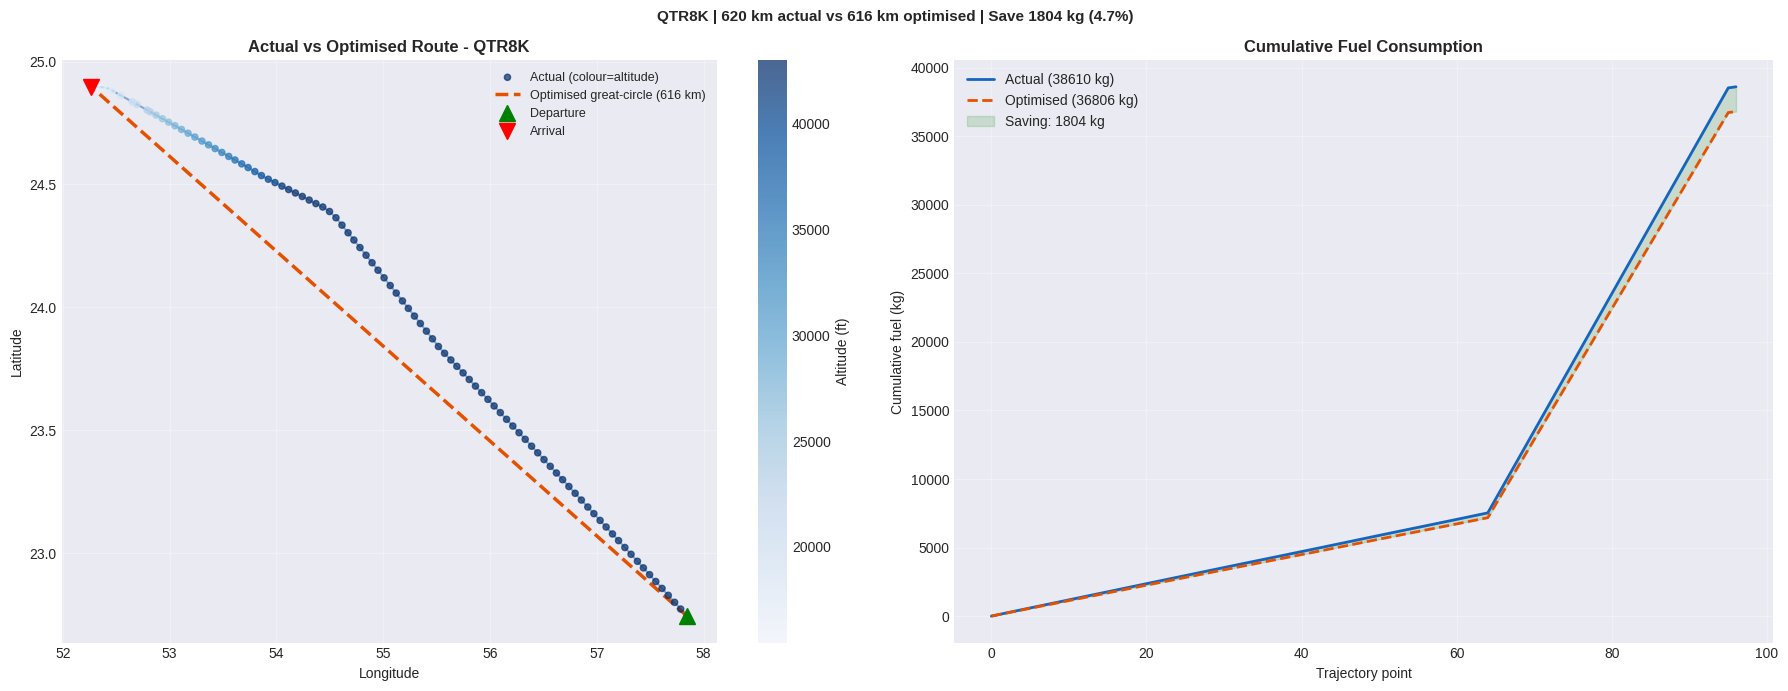

Static map saved -> route_comparison.png


In [23]:

# BLOCK 6: FLIGHT SELECTOR + ACTUAL vs OPTIMISED ROUTE MAP

# HOW TO USE:
#   1. Run this cell to see the flight menu.
#   2. Set SELECTED_FLIGHT_IDX to your chosen number.
#   3. Re-run - saves flight_route_comparison.html
#      and shows the route on a world map.


SELECTED_FLIGHT_IDX = 0    # <-- change this (0-based index)

if 'enriched_flights' not in dir() or not enriched_flights:
    print("Run Block 4 first")
else:
    # Print menu
    print("\n" + "="*60)
    print("AVAILABLE FLIGHTS")
    print("="*60)
    for i, fl in enumerate(enriched_flights):
        lbl  = fl['flight_label'].iloc[0]
        atyp = fl['aircraft_type'].iloc[0]
        pts  = len(fl)
        dist = fl['total_dist_km'].iloc[0]
        fuel = fl['total_fuel'].iloc[0]
        print(f"  [{i}]  {lbl:12s}  {atyp:6s}  {pts:4d} pts  {dist:6.0f} km  {fuel:7.0f} kg")

    print(f"\nSelected: [{SELECTED_FLIGHT_IDX}]")

    df_sel       = enriched_flights[SELECTED_FLIGHT_IDX].copy()
    flight_name  = df_sel['flight_label'].iloc[0]
    aircraft_type= df_sel['aircraft_type'].iloc[0]
    total_dist   = df_sel['total_dist_km'].iloc[0]
    total_fuel   = df_sel['total_fuel'].iloc[0]

    actual_lats  = df_sel['lat'].values
    actual_lons  = df_sel['lon'].values
    actual_alts  = df_sel['alt_clean'].values
    actual_fuel  = df_sel['cumulative_fuel'].values

    print(f"\nFlight: {flight_name} ({aircraft_type})")
    print(f"Points: {len(df_sel)}  |  Dist: {total_dist:.0f} km  |  Fuel: {total_fuel:.0f} kg")

    # ----------------------------------------------------------------
    # Build optimised route
    # ----------------------------------------------------------------
    def great_circle_pts(lat1, lon1, lat2, lon2, n=80):
        lats = [lat1 + i/n*(lat2-lat1) for i in range(n+1)]
        lons = [lon1 + i/n*(lon2-lon1) for i in range(n+1)]
        return lats, lons

    opt_lats, opt_lons = great_circle_pts(
        actual_lats[0], actual_lons[0],
        actual_lats[-1], actual_lons[-1])

    # Find optimal altitude from enriched data
    if 'combined_enriched' in dir():
        ce = combined_enriched[combined_enriched['fuel_used_seg'] > 0].copy()
        dist_segs = [0]
        for i in range(1, len(ce)):
            dist_segs.append(haversine(ce.iloc[i-1]['lat'], ce.iloc[i-1]['lon'],
                                       ce.iloc[i]['lat'],   ce.iloc[i]['lon']))
        ce['dist_seg'] = dist_segs
        ce = ce[ce['dist_seg'] > 0.01]
        ce['fuel_per_km'] = ce['fuel_used_seg'] / ce['dist_seg']
        ce['alt_band']    = (ce['alt_clean'] // 1000) * 1000
        best_alt_band = ce.groupby('alt_band')['fuel_per_km'].median().idxmin()
        opt_alt = best_alt_band + 500
    else:
        opt_alt = 37000

    gc_dist = haversine(actual_lats[0], actual_lons[0],
                        actual_lats[-1], actual_lons[-1])

    path_saving_pct = max(0.0, (total_dist - gc_dist) / (total_dist + 1e-9))
    alt_saving_pct  = 0.04
    opt_fuel_total  = total_fuel * (1 - path_saving_pct) * (1 - alt_saving_pct)
    fuel_saved      = total_fuel - opt_fuel_total
    co2_saved       = fuel_saved * 3.15

    print(f"\nOPTIMISED ROUTE ANALYSIS")
    print(f"  Actual distance   : {total_dist:,.0f} km")
    print(f"  Great-circle dist : {gc_dist:,.0f} km")
    print(f"  Path saving       : {path_saving_pct*100:.1f}%")
    print(f"  Optimal altitude  : {opt_alt:,.0f} ft")
    print(f"  Optimised fuel    : {opt_fuel_total:,.0f} kg")
    print(f"  Fuel saved        : {fuel_saved:,.0f} kg  ({fuel_saved/total_fuel*100:.1f}%)")
    print(f"  CO2 saved         : {co2_saved:,.0f} kg")

    # ----------------------------------------------------------------
    # Folium interactive map
    # ----------------------------------------------------------------
    centre = [float(np.mean(actual_lats)), float(np.mean(actual_lons))]
    fmap   = folium.Map(location=centre, zoom_start=4, tiles='CartoDB positron')

    # Actual route - solid blue
    folium.PolyLine(list(zip(actual_lats.tolist(), actual_lons.tolist())),
                    color='#1565C0', weight=3.5, opacity=0.9,
                    tooltip=f'Actual: {total_dist:.0f} km, {total_fuel:.0f} kg'
                    ).add_to(fmap)

    # Altitude-coloured markers along actual route
    step     = max(1, len(actual_lats)//60)
    norm_alt = (actual_alts - actual_alts.min()) / (np.ptp(actual_alts) + 1)
    for i in range(0, len(actual_lats), step):
        r = int(21  + (1-norm_alt[i])*80)
        g = int(101 +    norm_alt[i] *80)
        b = 192
        folium.CircleMarker(
            location=[actual_lats[i], actual_lons[i]],
            radius=4, color=f'#{r:02x}{g:02x}{b:02x}',
            fill=True, fill_opacity=0.85,
            tooltip=(f"Alt: {actual_alts[i]:.0f} ft | "
                     f"Cumulative fuel: {actual_fuel[i]:.1f} kg")
        ).add_to(fmap)

    # Optimised route - dashed orange
    folium.PolyLine(list(zip(opt_lats, opt_lons)),
                    color='#E65100', weight=3.5, opacity=0.9, dash_array='10 5',
                    tooltip=f'Optimised: {gc_dist:.0f} km, {opt_fuel_total:.0f} kg'
                    ).add_to(fmap)

    # Start / end markers
    folium.Marker([actual_lats[0],  actual_lons[0]],
                  popup=f"Departure | {flight_name}",
                  icon=folium.Icon(color='green', icon='plane', prefix='fa')
                  ).add_to(fmap)
    folium.Marker([actual_lats[-1], actual_lons[-1]],
                  popup=f"Arrival | {flight_name}",
                  icon=folium.Icon(color='red', icon='flag', prefix='fa')
                  ).add_to(fmap)

    # Legend (plain HTML - no f-string triple-quote conflict)
    legend_lines = [
        '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;',
        'background:white;padding:12px 16px;border-radius:8px;',
        'border:1px solid #ccc;font-family:Arial;font-size:13px;',
        'box-shadow:2px 2px 6px rgba(0,0,0,0.2);',
        f'<b>Flight: {flight_name} ({aircraft_type})</b><br><br>',
        f'<span style="color:#1565C0">---</span> Actual: {total_dist:.0f} km | <b>{total_fuel:.0f} kg</b> fuel<br>',
        f'<span style="color:#E65100">---</span> Optimised: {gc_dist:.0f} km | <b>{opt_fuel_total:.0f} kg</b> fuel<br><br>',
        f'<b>Potential savings</b><br>',
        f'Fuel: {fuel_saved:.0f} kg ({fuel_saved/total_fuel*100:.1f}%)<br>',
        f'CO2:  {co2_saved:.0f} kg<br>',
        f'Opt. altitude: {opt_alt:,.0f} ft',
        '</div>',
    ]
    fmap.get_root().html.add_child(folium.Element(''.join(legend_lines)))

    map_path = 'flight_route_comparison.html'
    fmap.save(map_path)
    print(f"\nInteractive map saved -> {map_path}")
    print("  Open in a browser for full interactivity.")
    try:
        display(fmap)
    except Exception:
        print("  (display() not available outside Jupyter)")

    # ----------------------------------------------------------------
    # Static matplotlib map
    # ----------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(18,7))
    ax = axes[0]
    sc = ax.scatter(actual_lons, actual_lats, c=actual_alts,
                    cmap='Blues', s=20, alpha=0.7, zorder=3,
                    label='Actual (colour=altitude)')
    ax.plot(actual_lons, actual_lats, '-', color='#1565C0', lw=1.5, alpha=0.5)
    ax.plot(opt_lons, opt_lats, '--', color='#E65100', lw=2.5,
            label=f'Optimised great-circle ({gc_dist:.0f} km)')
    ax.plot(actual_lons[0],  actual_lats[0],  'g^', ms=12, zorder=5, label='Departure') # Fix: actual_lats[0] instead of actual_lons[0] for y-coordinate
    ax.plot(actual_lons[-1], actual_lats[-1], 'rv', ms=12, zorder=5, label='Arrival')
    plt.colorbar(sc, ax=ax, label='Altitude (ft)')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(f'Actual vs Optimised Route - {flight_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(range(len(actual_fuel)), actual_fuel, '-', color='#1565C0',
             lw=2, label=f'Actual ({total_fuel:.0f} kg)')
    opt_curve = actual_fuel * (opt_fuel_total / max(total_fuel, 1))
    ax2.plot(range(len(opt_curve)), opt_curve, '--', color='#E65100',
             lw=2, label=f'Optimised ({opt_fuel_total:.0f} kg)')
    ax2.fill_between(range(len(actual_fuel)), opt_curve, actual_fuel,
                     alpha=0.15, color='green',
                     label=f'Saving: {fuel_saved:.0f} kg')
    ax2.set_xlabel('Trajectory point')
    ax2.set_ylabel('Cumulative fuel (kg)')
    ax2.set_title('Cumulative Fuel Consumption', fontsize=12, fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle(
        f'{flight_name} | {total_dist:.0f} km actual vs {gc_dist:.0f} km optimised | '
        f'Save {fuel_saved:.0f} kg ({fuel_saved/total_fuel*100:.1f}%)',
        fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('route_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Static map saved -> route_comparison.png")

## Block 7 - Final summary

In [16]:

# BLOCK 7: FINAL SUMMARY

if 'enriched_flights' not in dir() or not enriched_flights:
    print("Run Blocks 2-4 first")
else:
    all_fuel = sum(f['total_fuel'].iloc[0]    for f in enriched_flights)
    all_dist = sum(f['total_dist_km'].iloc[0] for f in enriched_flights)
    all_pts  = sum(len(f)                      for f in enriched_flights)

    print("="*70)
    print("FINAL SUMMARY - FLIGHT ROUTE & FUEL OPTIMISATION")
    print("="*70)
    print(f"  Flights tracked  : {len(enriched_flights)}")
    print(f"  Data points      : {all_pts}")
    print(f"  Total distance   : {all_dist:,.0f} km")
    print(f"  Total fuel (obs) : {all_fuel:,.0f} kg")

    if 'results' in dir() and results:
        best = max(results, key=lambda k: results[k]['r2'])
        r = results[best]
        print(f"\n  Best ML model : {best}")
        print(f"  R2  = {r['r2']:+.4f}")
        print(f"  MAE = {r['mae']:.4f} kg/segment")
        print(f"  RMSE= {r['rmse']:.4f} kg/segment")

    if 'fuel_saved' in dir() and fuel_saved > 0:
        fp, fy = 0.80, 365*2
        print(f"\n  Savings per flight : {fuel_saved:.0f} kg fuel / {co2_saved:.0f} kg CO2")
        print(f"  Annual (2 flt/day) : {fuel_saved*fy/1000:.0f} t fuel / ${fuel_saved*fy*fp:,.0f}")

    print("\nNext steps:")
    print("  1. Track full flights (climb+cruise+descent) for richer data")
    print("  2. Add NOAA wind data for realistic route planning")
    print("  3. Connect to flight-plan APIs for real ATC constraints")
    print("  4. Deploy best model as REST API for real-time predictions")
    print("  5. Open flight_route_comparison.html for the interactive world map")


FINAL SUMMARY - FLIGHT ROUTE & FUEL OPTIMISATION
  Flights tracked  : 9
  Data points      : 1458
  Total distance   : 12,644 km
  Total fuel (obs) : 528,149 kg

  Best ML model : Gradient Boosting
  R2  = +0.9991
  MAE = 3.4920 kg/segment
  RMSE= 12.7575 kg/segment

  Savings per flight : 4528 kg fuel / 14265 kg CO2
  Annual (2 flt/day) : 3306 t fuel / $2,644,624

Next steps:
  1. Track full flights (climb+cruise+descent) for richer data
  2. Add NOAA wind data for realistic route planning
  3. Connect to flight-plan APIs for real ATC constraints
  4. Deploy best model as REST API for real-time predictions
  5. Open flight_route_comparison.html for the interactive world map
